# Sequential ViDA: APTOS → IDRiD → APTOS (VisionFM)

Protocol:
1. Load VisionFM pretrained weights
2. Evaluate baseline on source domain (APTOS)
3. Adapt to target domain (IDRiD) - adaptation mode
4. Evaluate on ALL previous domains (APTOS, IDRiD) - TEST mode

This measures catastrophic forgetting: after adapting to IDRiD,
how much performance degrades on APTOS?

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
config = load_config('configs/method/sequential/vida/aptos_idrid_visionfm.yaml')

print('Protocol: Sequential ViDA')
print(f'Source: {config.sequential.source_dataset.name}')
print(f'Targets: {[t.name for t in config.sequential.target_datasets]}')
print('Method:', config.ctta.method)
print('Model:', config.model.name)
print('Output:', config.output_dir)

# RETFound weights are gated behind HuggingFace; require a token.
if config.model.name == 'retfound' and not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN set')
elif config.model.name != 'retfound':
    print('No HF token needed (VisionFM / Google Drive)')

Protocol: Sequential ViDA
Source: aptos2019
Targets: ['idrid']
Method: cotta
Model: visionfm
Output: ./outputs/sequential_vida/aptos_idrid_visionfm/
No HF token needed (VisionFM / Google Drive)


In [4]:
from src.evaluation.runner import SequentialCTTARunner

runner = SequentialCTTARunner(config)
results = runner.run()

2026-08-05 10:20:18,123 - src.evaluation.runner.sequential - INFO - Starting sequential CTTA: aptos2019 -> idrid
2026-08-05 10:20:18,217 - src.models.visionfm_download - INFO - Downloading VisionFM Fundus weights from Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=13uWm0a02dCWyARUcrCdHZIcEgRfBmVA4
From (redirected): https://drive.google.com/uc?id=13uWm0a02dCWyARUcrCdHZIcEgRfBmVA4&confirm=t&uuid=9670f137-1f8e-44c0-9061-f39c6b87fbb2
To: /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
100%|██████████| 1.51G/1.51G [00:11<00:00, 131MB/s] 

2026-08-05 10:20:31,459 - src.models.visionfm_download - INFO - VisionFM Fundus weights downloaded to ./cache/visionfm/VFM_Fundus_weights.pth


2026-08-05 10:20:32,658 - src.models.visionfm - INFO - Loading VisionFM checkpoint from /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
2026-08-05 10:20:33,707 - src.models.visionfm - INFO - Extracted state_dict from 'teacher' key
2026-08-05 10:20:33,708 - src.models.visionfm - INFO - Stripped 'backbone.' prefix from 160 state dict keys
2026-08-05 10:20:33,776 - src.models.visionfm - INFO - VisionFM checkpoint cached in CPU RAM
2026-08-05 10:20:33,814 - src.models.visionfm - INFO - Frozen first 8 of 12 transformer blocks
2026-08-05 10:20:33,815 - src.models.visionfm - INFO - Feature normalization ENABLED in forward()
2026-08-05 10:20:34,161 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
2026-08-05 10:22:54,221 - src.evaluation.runner.base - INFO - Prototype weights scaled by T=50.0
2026-08-05 10:22:54,224 - src.evaluation.runner.base - INFO - Prototype classifier initialized from 2930 training samples (5 classes, 3072-dim features, T=50.0)
2

Adapting to aptos2019:   0%|          | 0/23 [00:00<?, ?it/s]

...

Adapting to idrid:  86%|████████▌ | 6/7 [00:39<00:06,  6.05s/it, acc=0.4375, adaptations=6]

2026-08-05 10:26:43,558 - src.evaluation.runner.sequential - INFO -   Adapt step 6: loss=0.0437, kl=0.0437, conf_samples=-1, teacher_max_prob=-1.0000


Adapting to idrid: 100%|██████████| 7/7 [00:41<00:00,  5.95s/it, acc=0.4286, adaptations=7]

2026-08-05 10:26:43,686 - src.evaluation.runner.sequential - INFO - Evaluating after adaptation on idrid


2026-08-05 10:26:51,820 - src.evaluation.runner.sequential - INFO - Post-adaptation QWK: 0.6356
2026-08-05 10:26:51,823 - src.evaluation.runner.sequential - INFO - Adaptations: 7/7
2026-08-05 10:26:51,902 - src.evaluation.runner.sequential - INFO - 
Evaluating on all 2 seen domains after adapting to idrid
2026-08-05 10:26:51,903 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on aptos2019 (no adaptation)
2026-08-05 10:27:09,945 - src.evaluation.runner.sequential - INFO -   QWK on aptos2019: 0.7533
2026-08-05 10:27:16,297 - src.evaluation.runner.sequential - INFO -   QWK on idrid: 0.6356
2026-08-05 10:27:16,299 - src.evaluation.runner.sequential - INFO - 
2026-08-05 10:27:16,300 - src.evaluation.runner.sequential - INFO - Sequential CTTA Complete - Summary
2026-08-05 10:27:16,301 - src.evaluation.runner.sequential - INFO - ============================================================
2026-08-05 10:27:16,302 - src.evaluation.runner.sequential - INFO - Baseline QWK (apto

============== Sequential CTTA Results (ViDA VisionFM) ===============

Source domain: aptos2019
  Baseline QWK:           0.7552
  Baseline Overall Acc:   71.04%

Target domains: idrid

----------------------------------------------------------------------
After adapting to source aptos2019 (23/23 batches):
  QWK:                  0.7559  (delta: +0.0007)
  Overall Acc:          70.77% (delta: -0.27pp)

----------------------------------------------------------------------
After adapting to idrid (7/7 batches):
  Post-adaptation QWK on idrid: 0.6356
  Post-adaptation Acc on idrid: 49.51%
  Test on aptos2019:
    QWK: 0.7533  (delta vs baseline: -0.0020)
    Acc: 70.49% (delta vs baseline: -0.55pp)



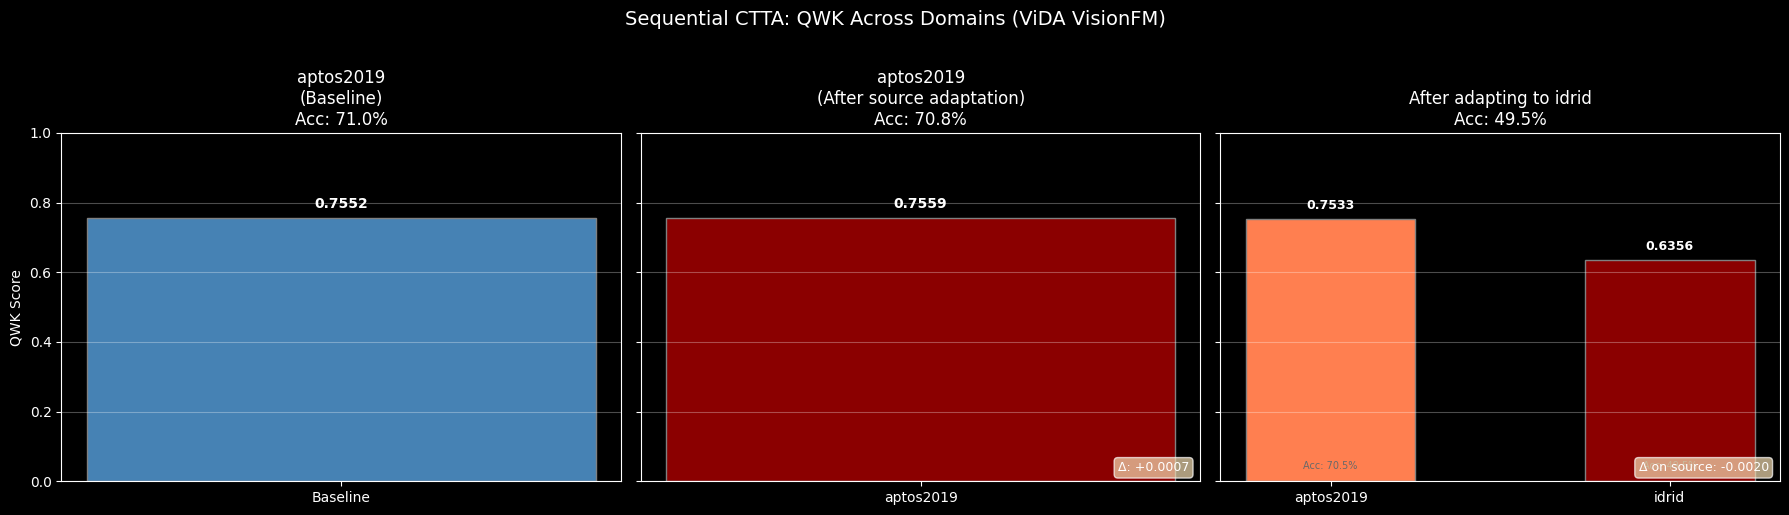

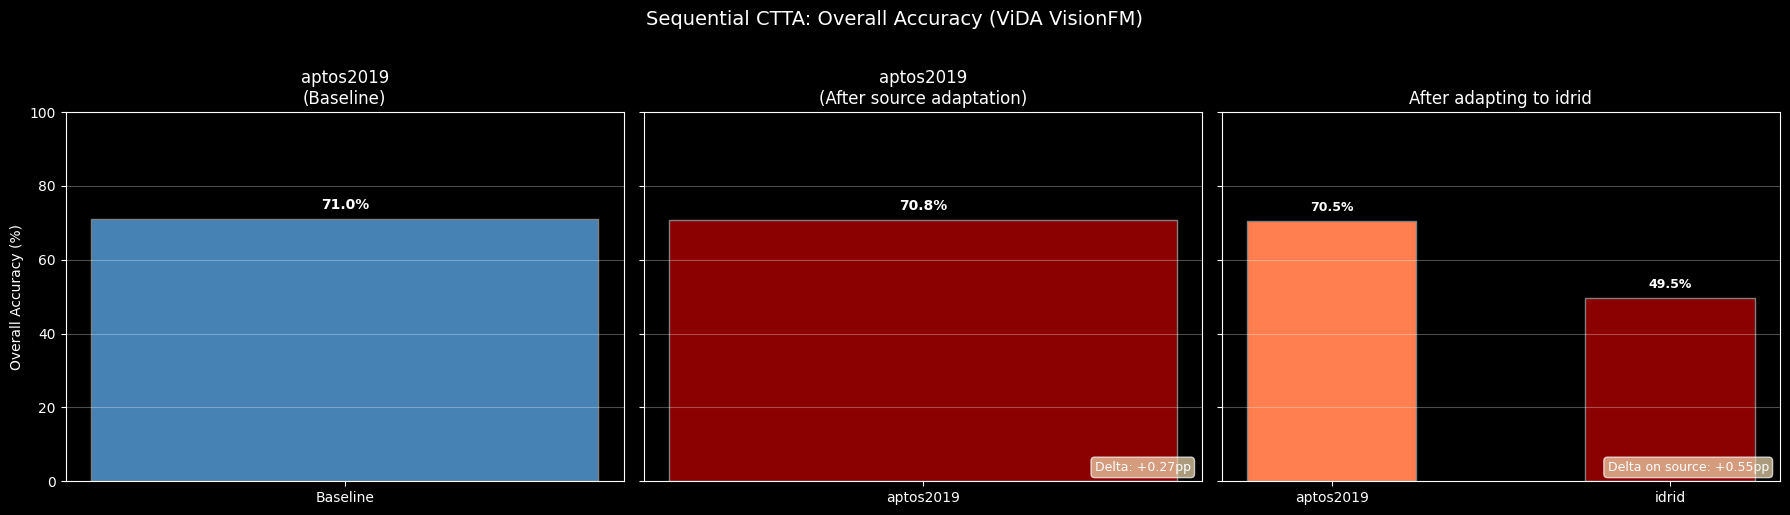

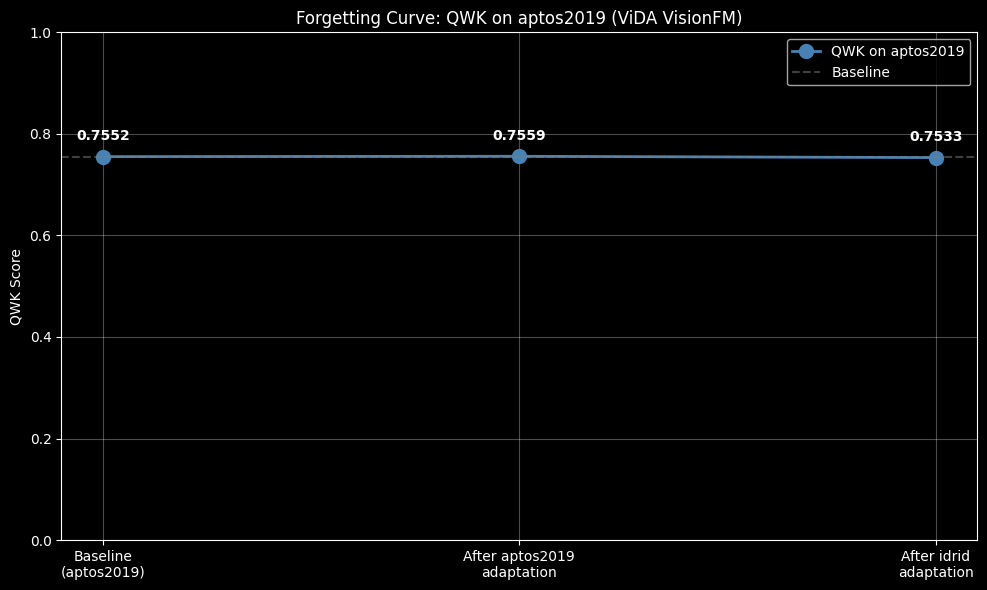

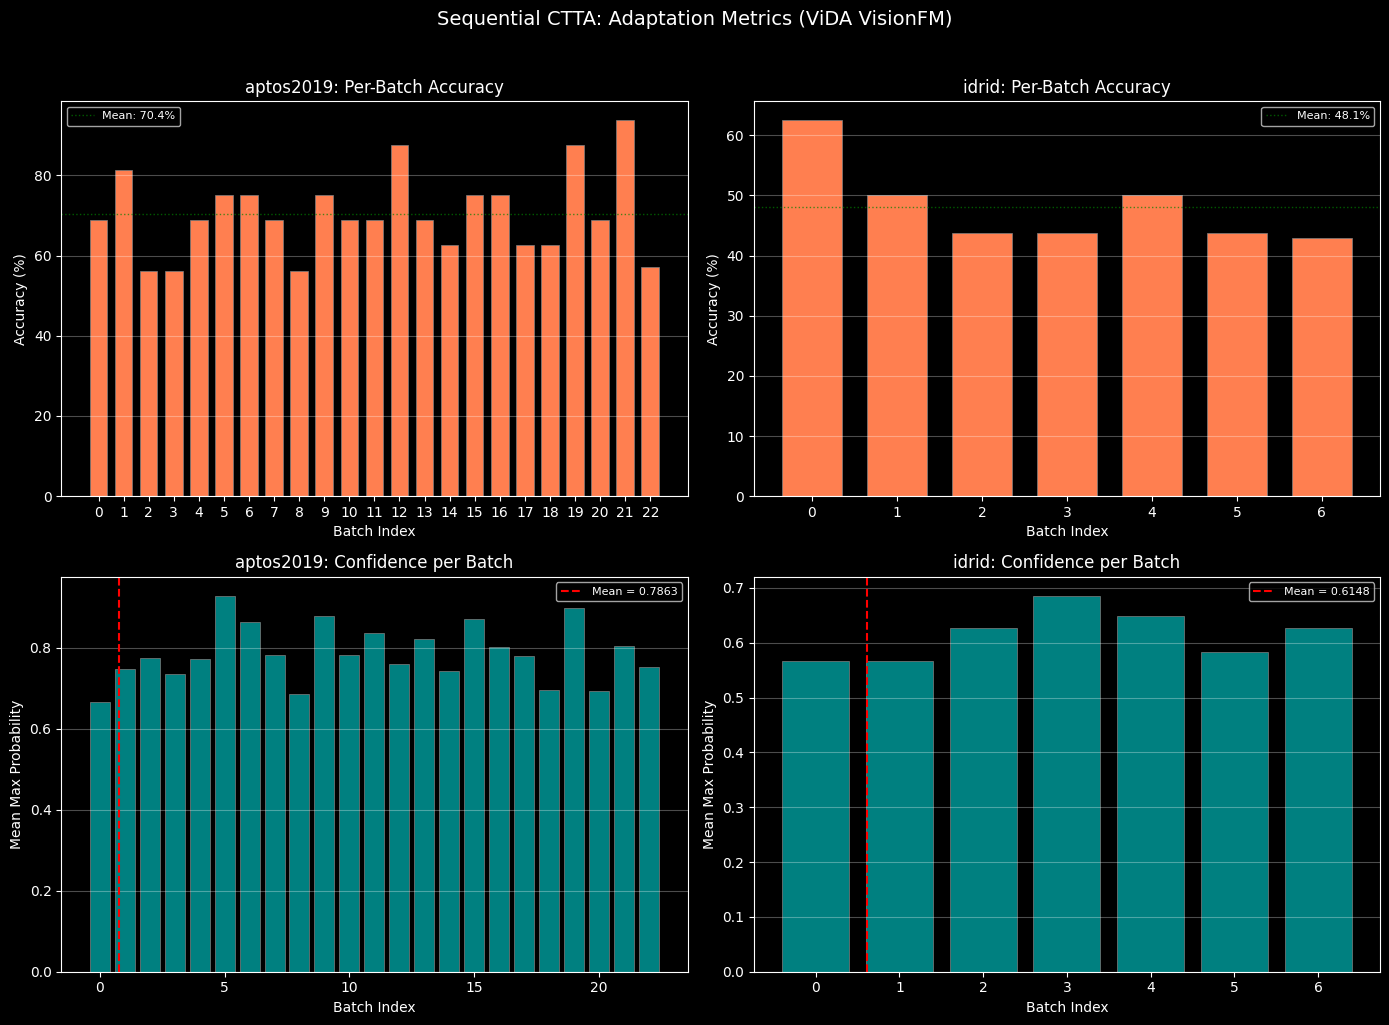

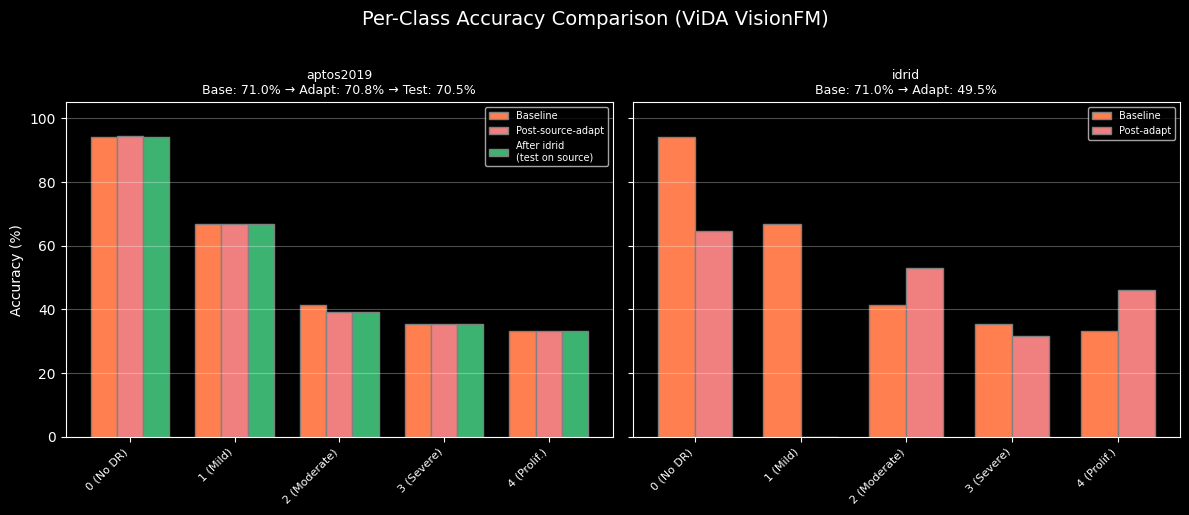

In [5]:
from pathlib import Path
from src.viz import (
    load_standalone_results,
    plot_sequential_qwk_comparison,
    plot_sequential_overall_accuracy,
    plot_sequential_forgetting,
    plot_sequential_adaptation_comparison,
    plot_sequential_per_class_accuracy,
    print_sequential_summary,
)

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

print_sequential_summary(results, method_name='ViDA VisionFM')
plot_sequential_qwk_comparison(results, plots_dir, method_name='ViDA VisionFM')
plot_sequential_overall_accuracy(results, plots_dir, method_name='ViDA VisionFM')
plot_sequential_forgetting(results, plots_dir, method_name='ViDA VisionFM')
plot_sequential_adaptation_comparison(results, plots_dir, method_name='ViDA VisionFM')
plot_sequential_per_class_accuracy(results, plots_dir, method_name='ViDA VisionFM')